In [56]:
import pandas as pd

rawData = {
    'TTS Tool': [
         'Meta’s MMS', 'Bhashini',
        'Google Cloud', 'Indic TTS', 'gTTS'
    ],
    'WER': [ 0.20, 0.18, 0.09, 0.24, 0.16],
    'MCD': [ 5.66, 5.11, 2.51, 5.22, 2.77],
    'F0_RMSE': [ 119, 115, 102, 121, 99]
}

df = pd.DataFrame(rawData)

# Inverse Min–Max Normalization Formula (3.6)
# MMN = 1 - (x - min(x)) / (max(x) - min(x))

def inverse_min_max_normalization(column):
    return 1 - (column - column.min()) / (column.max() - column.min())

df_normalized = df.copy()
df_normalized['WER'] = inverse_min_max_normalization(df['WER'])
df_normalized['MCD'] = inverse_min_max_normalization(df['MCD'])
df_normalized['F0_RMSE'] = inverse_min_max_normalization(df['F0_RMSE'])


# Define Weights accoridng your scenario (Sum = 1)
weights = {
    "WER": 0.35,
    "MCD": 0.25,
    "F0_RMSE": 0.30
}

# Weighted Sum Model (WSM)
df_normalized["WSM_Score"] = (
    weights["WER"] * df_normalized["WER"] +
    weights["MCD"] * df_normalized["MCD"] +
    weights["F0_RMSE"] * df_normalized["F0_RMSE"]
)


# Ranking
df_normalized["Rank"] = df_normalized["WSM_Score"].rank(
    ascending=False, method="dense"
)

df_final = df_normalized.sort_values(
    by="WSM_Score", ascending=False
)

print("\nFinal WSM Scores and Ranking of TTS tools:\n")
print(df_final)



Final WSM Scores and Ranking of TTS tools:

       TTS Tool       WER       MCD   F0_RMSE  WSM_Score  Rank
2  Google Cloud  1.000000  1.000000  0.863636   0.859091   1.0
4          gTTS  0.533333  0.917460  1.000000   0.716032   2.0
1      Bhashini  0.400000  0.174603  0.272727   0.265469   3.0
0    Meta’s MMS  0.266667  0.000000  0.090909   0.120606   4.0
3     Indic TTS  0.000000  0.139683  0.000000   0.034921   5.0


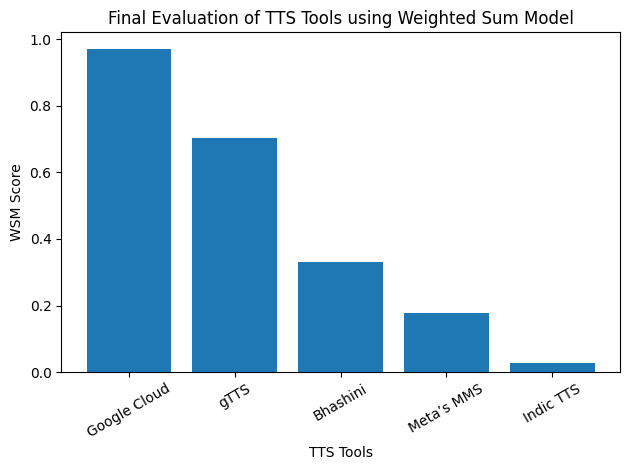

In [46]:
import matplotlib.pyplot as plt

# Bar chart for WSM Scores
plt.figure()
plt.bar(df_final["TTS Tool"], df_final["WSM_Score"])
plt.xlabel("TTS Tools")
plt.ylabel("WSM Score")
plt.title("Final Evaluation of TTS Tools using Weighted Sum Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


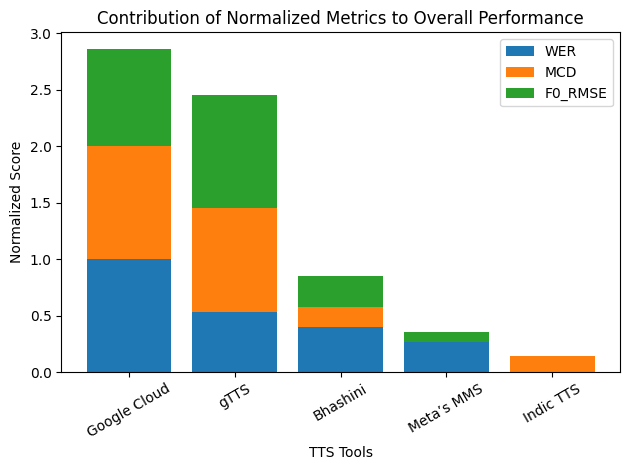

In [47]:
# Bar chart for Normalized Metrics
plt.figure()
plt.bar(df_final["TTS Tool"], df_final["WER"], label="WER")
plt.bar(df_final["TTS Tool"], df_final["MCD"], bottom=df_final["WER"], label="MCD")
plt.bar(
    df_final["TTS Tool"],
    df_final["F0_RMSE"],
    bottom=df_final["WER"] + df_final["MCD"],
    label="F0_RMSE"
)

plt.xlabel("TTS Tools")
plt.ylabel("Normalized Score")
plt.title("Contribution of Normalized Metrics to Overall Performance")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


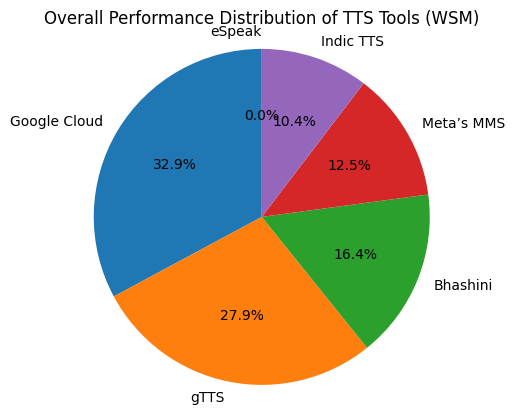

In [28]:
plt.figure()
plt.pie(
    df_final["WSM_Score"],
    labels=df_final["TTS Tool"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Overall Performance Distribution of TTS Tools (WSM)")
plt.axis('equal')
plt.show()
